# Dataset
Oxford Pet Dataset

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install torchvision

In [2]:
import torchvision
from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt
import numpy as np
import random
import os
import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw

In [3]:
#Load dataset
dataset = OxfordIIITPet(root='./data', download=True)

100%|██████████| 792M/792M [00:37<00:00, 20.9MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.3MB/s]


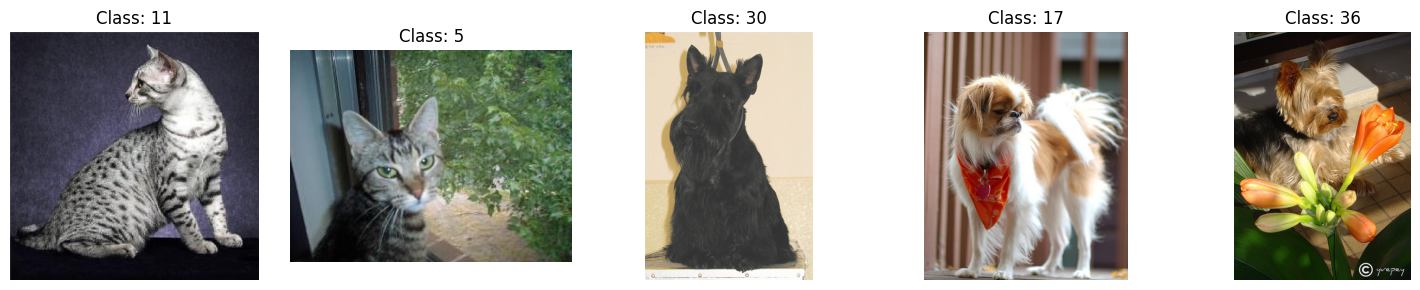

In [4]:
# Display sample
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    random_integer = random.randint(0, len(dataset))
    img, target = dataset[random_integer]
    img_np = np.array(img)
    axes[i].imshow(img_np)
    axes[i].set_title(f"Class: {target}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

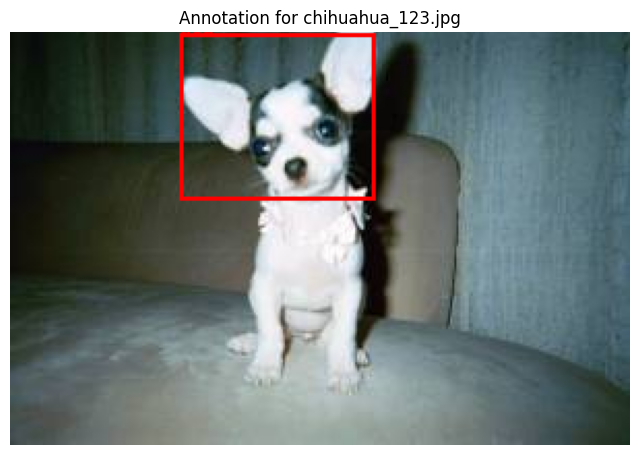

In [5]:
data_dir = './data/oxford-iiit-pet'
images_dir = os.path.join(data_dir, 'images')
annotations_dir = os.path.join(data_dir, 'annotations', 'xmls')

# List all xml files
xml_files = [f for f in os.listdir(annotations_dir) if f.endswith('.xml')]

# Select a random XML file
random_xml_file = random.choice(xml_files)
xml_path = os.path.join(annotations_dir, random_xml_file)

# Parse the XML file
tree = ET.parse(xml_path)
root = tree.getroot()

# Extract image file name
image_filename = root.find('filename').text
image_path = os.path.join(images_dir, image_filename)

# Open the image
image = Image.open(image_path).convert("RGB")
draw = ImageDraw.Draw(image)

# Extract and draw bounding boxes
for obj in root.findall('object'):
    bndbox = obj.find('bndbox')
    xmin = int(bndbox.find('xmin').text)
    ymin = int(bndbox.find('ymin').text)
    xmax = int(bndbox.find('xmax').text)
    ymax = int(bndbox.find('ymax').text)
    class_name = obj.find('name').text

    # Draw rectangle on the image
    draw.rectangle([(xmin, ymin), (xmax, ymax)], outline="red", width=2)
    # Optionally add text
    draw.text((xmin, ymin - 10), class_name, fill="red")

# Display the image with bounding box
plt.figure(figsize=(8, 8))
plt.imshow(np.array(image))
plt.title(f"Annotation for {image_filename}")
plt.axis('off')
plt.show()

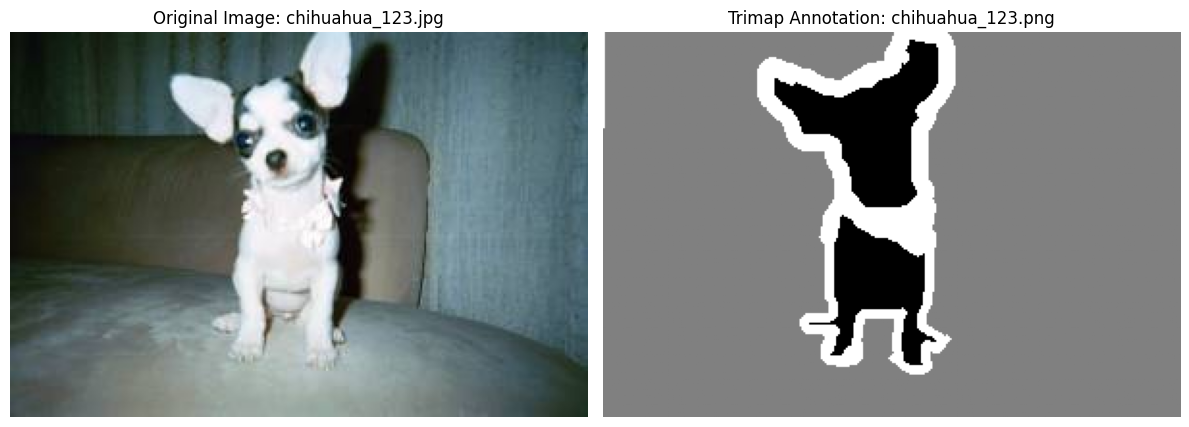

In [6]:
# Get the directory containing the trimap annotations
trimaps_dir = os.path.join(data_dir, 'annotations', 'trimaps')

# List all trimap files
trimap_files = [f for f in os.listdir(trimaps_dir) if f.endswith('.png')]

# The image file name should correspond to the trimap file name (excluding extension)
trimap_filename_base = os.path.splitext(random_xml_file)[0]
trimap_filename = f"{trimap_filename_base}.png"
trimap_path = os.path.join(trimaps_dir, trimap_filename)

# Check if the corresponding trimap file exists
if not os.path.exists(trimap_path):
    print(f"Trimap file not found for {image_filename}: {trimap_path}")
else:
    # Open the trimap image
    trimap_image = Image.open(trimap_path)

    # Display the original image and the trimap side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Display the original image (without bounding boxes for clarity)
    original_image_path = os.path.join(images_dir, image_filename)
    original_image = Image.open(original_image_path).convert("RGB")
    axes[0].imshow(np.array(original_image))
    axes[0].set_title(f"Original Image: {image_filename}")
    axes[0].axis('off')

    # Display the trimap
    axes[1].imshow(np.array(trimap_image), cmap='gray') # Trimaps are grayscale
    axes[1].set_title(f"Trimap Annotation: {trimap_filename}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# 1. U-Net (Semantic Segmentation)

**🎯 Objective:**  
Train a U-Net model to segment objects in an image using semantic segmentation.

- **Load image & binary mask**  
  Use a dataset that provides both input images and segmentation masks (e.g., Oxford-IIIT Pet).

- **Preprocess (Resize & Normalize)**  
  Standardize image dimensions (e.g., 128x128) and normalize pixel values.  
  Convert masks to binary format (0 = background, 1 = object).

- **Build a Simple U-Net Model**  
  Design an encoder-decoder architecture with skip connections to capture both global and local context.

- **Train on a Few Images**  
  Fit the model using a small dataset subset to test functionality and convergence.

- **Visualize Predictions**  
  Compare predicted segmentation masks with ground truth side-by-side.



In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.datasets import OxfordIIITPet
import albumentations as A
from albumentations.pytorch import ToTensorV2

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

In [8]:
# Training transform with augmentations and preprocessing
albumentations_train = A.Compose([
    A.Resize(128, 128),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

# Validation transform (no augmentation)
albumentations_val = A.Compose([
    A.Resize(128, 128),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

In [9]:
# Dataset wrapper
class PetSegDataset(Dataset):
    def __init__(self, base_dataset, transform=None):
        self.base = base_dataset
        self.transform = transform

    def __getitem__(self, idx):
        image, mask = self.base[idx]
        image = np.array(image)
        mask = np.array(mask)

        # Only keep the pet class
        mask = (mask == 1).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].unsqueeze(0)  # [1, H, W]

        return image, mask

    def __len__(self):
        return len(self.base)


In [10]:
# Reload dataset and apply the transformation
# Original dataset (no transform here)
oxford_dataset = OxfordIIITPet(root='./data', download=True, target_types='segmentation')

# Train/Val split
train_size = int(0.8 * len(oxford_dataset))
val_size = len(oxford_dataset) - train_size
oxford_train, oxford_val = random_split(oxford_dataset, [train_size, val_size])

# Apply Albumentations
train_data = PetSegDataset(oxford_train, transform=albumentations_train)
val_data = PetSegDataset(oxford_val, transform=albumentations_val)

# DataLoaders
train_loader = DataLoader(train_data, batch_size=4, shuffle=True)
val_loader = DataLoader(val_data, batch_size=4)

In [11]:
# Initiate U-Net
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        def CBR(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU()
            )
        self.enc1 = CBR(3, 16)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = CBR(16, 32)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = CBR(32, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = CBR(64, 32)
        self.up2 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec2 = CBR(32, 16)

        self.final = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))

        d1 = self.up1(b)
        d1 = torch.cat([d1, e2], dim=1)
        d1 = self.dec1(d1)

        d2 = self.up2(d1)
        d2 = torch.cat([d2, e1], dim=1)
        d2 = self.dec2(d2)

        return torch.sigmoid(self.final(d2))

In [12]:
def dice_coefficient(preds, targets, threshold=0.5, eps=1e-6):
    # Apply threshold to predictions
    preds = (preds > threshold).float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    dice = (2. * intersection + eps) / (union + eps)
    return dice.mean().item()


In [13]:
# Training with Dice Score evaluation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()
num_epochs = 10

# Training
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    # === Evaluation ===
    model.eval()
    dice_scores = []

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)
            dice = dice_coefficient(preds, masks)
            dice_scores.append(dice)

    avg_dice = sum(dice_scores) / len(dice_scores)

    print(f"Epoch {epoch+1} - Loss: {avg_loss:.4f} - Dice Score: {avg_dice:.4f}")


Epoch 1 - Loss: 0.5311 - Dice Score: 0.5097
Epoch 2 - Loss: 0.4840 - Dice Score: 0.4945
Epoch 3 - Loss: 0.4785 - Dice Score: 0.4881
Epoch 4 - Loss: 0.4737 - Dice Score: 0.5514
Epoch 5 - Loss: 0.4677 - Dice Score: 0.6200
Epoch 6 - Loss: 0.4551 - Dice Score: 0.5220
Epoch 7 - Loss: 0.4276 - Dice Score: 0.6403
Epoch 8 - Loss: 0.4010 - Dice Score: 0.6941
Epoch 9 - Loss: 0.3915 - Dice Score: 0.7308
Epoch 10 - Loss: 0.3704 - Dice Score: 0.6944


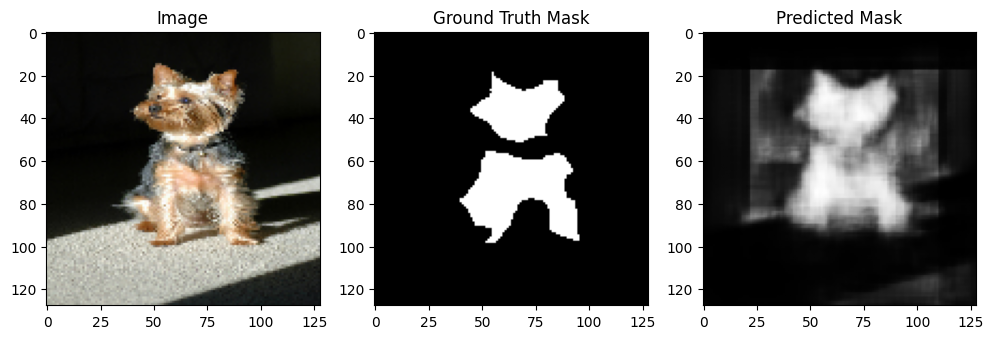

In [14]:
random_val = random.randint(0, len(val_data))
with torch.no_grad():
    sample_img, sample_mask = val_data[random_val]
    sample_img_input = sample_img.unsqueeze(0).to(device)
    pred_mask = model(sample_img_input).squeeze().cpu().numpy()

    # De-normalize the image for visualization
    img_show = sample_img.permute(1, 2, 0).cpu().numpy()
    img_show = (img_show * 0.5) + 0.5  # From [-1, 1] to [0, 1]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img_show)
    plt.title("Image")

    plt.subplot(1, 3, 2)
    plt.imshow(sample_mask.squeeze().numpy(), cmap='gray')
    plt.title("Ground Truth Mask")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap='gray')
    plt.title("Predicted Mask")

    plt.show()


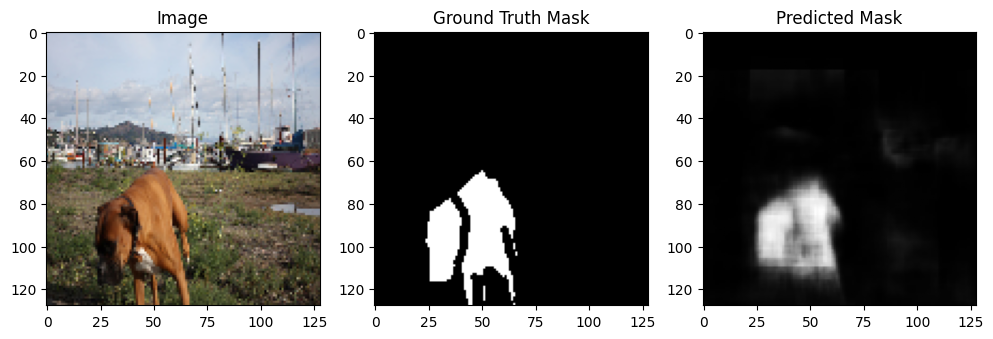

Dice Coefficient for this sample: 0.1589


In [15]:
random_val = random.randint(0, len(val_data))
with torch.no_grad():
    sample_img, sample_mask = val_data[random_val]
    sample_img_input = sample_img.unsqueeze(0).to(device)  # Add batch dim

    # Predict
    output = model(sample_img_input)
    pred_mask = torch.sigmoid(output).squeeze().cpu().numpy()

    # De-normalize image for display
    img_show = sample_img.permute(1, 2, 0).cpu().numpy()
    img_show = (img_show * 0.5) + 0.5  # From [-1,1] to [0,1]

    # Plot
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img_show)
    plt.title("Image")

    plt.subplot(1, 3, 2)
    plt.imshow(sample_mask.squeeze().numpy(), cmap='gray')
    plt.title("Ground Truth Mask")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap='gray')  # No threshold
    plt.title("Predicted Mask")

    plt.show()

    # Dice Coefficient calculation
    # Threshold prediction
    pred_binary = (pred_mask > 0.5).astype(np.float32)
    gt_binary = sample_mask.squeeze().numpy().astype(np.float32)

    # Flatten
    pred_flat = pred_binary.flatten()
    gt_flat = gt_binary.flatten()

    # Dice calculation
    intersection = (pred_flat * gt_flat).sum()
    dice = (2. * intersection + 1e-6) / (pred_flat.sum() + gt_flat.sum() + 1e-6)

    print(f"Dice Coefficient for this sample: {dice:.4f}")


# 2. Mask R-CNN (Instance Segmentation)

### 🎯 Objectives:
- Wrap the Oxford Pet dataset for use with Mask R-CNN
- Train a Mask R-CNN model with a ResNet50 + FPN backbone
- Visualize predictions and compare them with ground truth
- Evaluate segmentation performance using **Dice Coefficient**

> ⚠️ For simplicity and speed, we limit training to a small subset and resized images. You can scale this up for more accurate results.


In [16]:
import torch
import torchvision
import numpy as np
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import cv2
import random
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.models.detection import MaskRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.datasets import OxfordIIITPet

In [17]:
# 1. Dataset Wrapper
class InstanceSegmentationDataset(Dataset):
    def __init__(self, base_dataset, transform=None):
        self.base = base_dataset
        self.transform = transform

    def __getitem__(self, idx):
        image, mask = self.base[idx]
        image = np.array(image)
        mask = np.array(mask)

        # Resize for speed
        image = cv2.resize(image, (128, 128))
        mask = cv2.resize(mask, (128, 128), interpolation=cv2.INTER_NEAREST)

        obj_ids = np.unique(mask)
        obj_ids = obj_ids[obj_ids == 1]  # Only pet label

        masks = mask == obj_ids[:, None, None] if len(obj_ids) > 0 else np.zeros((0, mask.shape[0], mask.shape[1]), dtype=np.uint8)

        boxes = []
        for m in masks:
            pos = np.where(m)
            if pos[0].size == 0:
                continue
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])
            boxes.append([xmin, ymin, xmax, ymax])

        if len(boxes) == 0:
            return self.__getitem__((idx + 1) % len(self))  # Skip invalid

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        h, w = mask.shape
        boxes[:, 0::2].clamp_(0, w)
        boxes[:, 1::2].clamp_(0, h)

        labels = torch.ones((len(boxes),), dtype=torch.int64)
        masks = torch.as_tensor(masks, dtype=torch.uint8)
        image = TF.to_tensor(image)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks
        }

        return image, target

    def __len__(self):
        return len(self.base)

In [18]:
# 2. Load Base Dataset
base_dataset = OxfordIIITPet(root="./data", target_types="segmentation", download=True)
full_dataset = InstanceSegmentationDataset(base_dataset)

subset_indices = 50 # increase this to add more dataset
# Filter valid indices only (masks with objects)
valid_indices = []
for i in range(len(full_dataset)):
    try:
        img, target = full_dataset[i]
        if target["masks"].shape[0] > 0:
            valid_indices.append(i)
        if len(valid_indices) >= subset_indices:  # Or increase this to full size later
            break
    except:
        continue

# This will use only subset of the dataset for faster training
# indices = list(range(40))
train_loader = DataLoader(Subset(full_dataset, valid_indices), batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

# Enable this to use the full dataset, beware the long duration of training
# train_loader = DataLoader(full_dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))


In [19]:
# 3. Model Initialization
backbone = resnet_fpn_backbone('resnet50', pretrained=True)
model = MaskRCNN(backbone, num_classes=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'backbone_name' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 216MB/s]


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu):

In [20]:
# 4. Training Loop
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9)

model.train()
for epoch in range(20):
    epoch_loss = 0
    for images, targets in train_loader:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        if torch.isnan(losses):
            continue  # Skip batch if NaN

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")


Epoch 1, Loss: 39.5520
Epoch 2, Loss: 23.9792
Epoch 3, Loss: 21.1206
Epoch 4, Loss: 20.4482
Epoch 5, Loss: 20.7479
Epoch 6, Loss: 20.5964
Epoch 7, Loss: 20.7288
Epoch 8, Loss: 20.2472
Epoch 9, Loss: 18.6310
Epoch 10, Loss: 21.2713
Epoch 11, Loss: 20.9586
Epoch 12, Loss: 20.7369
Epoch 13, Loss: 20.8244
Epoch 14, Loss: 18.5349
Epoch 15, Loss: 17.3185
Epoch 16, Loss: 17.5619
Epoch 17, Loss: 16.2725
Epoch 18, Loss: 16.0714
Epoch 19, Loss: 15.1262
Epoch 20, Loss: 16.8846


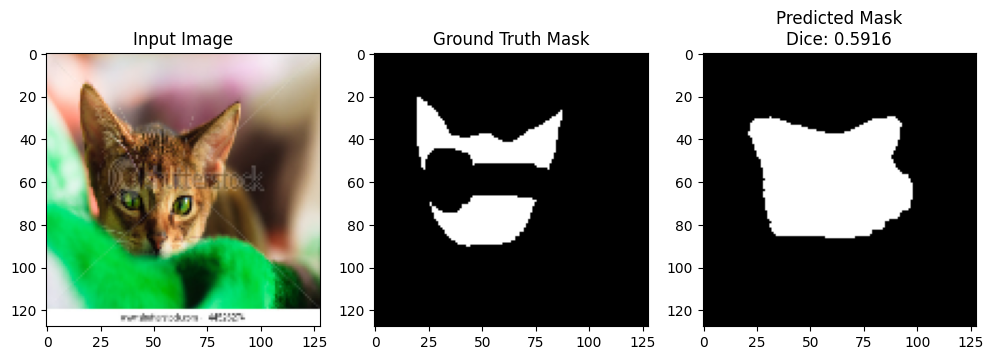

In [21]:
# 5. Inference on One Image
random_val = random.randint(0, len(full_dataset))
model.eval()
image, target = full_dataset[1]
with torch.no_grad():
    prediction = model([image.to(device)])

image_np = image.permute(1, 2, 0).numpy()
if len(prediction[0]['masks']) > 0:
    pred_mask = prediction[0]['masks'][0, 0].cpu().numpy()
else:
    pred_mask = np.zeros((128, 128))

def dice_coefficient(pred, true, epsilon=1e-6):
    pred = pred.astype(np.bool_)
    true = true.astype(np.bool_)
    intersection = np.logical_and(pred, true).sum()
    return (2. * intersection) / (pred.sum() + true.sum() + epsilon)

true_mask = target['masks'][0].numpy()
thresholded_pred = pred_mask > 0.5
dice_score = dice_coefficient(thresholded_pred, true_mask)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("Input Image")

plt.subplot(1, 3, 2)
plt.imshow(true_mask, cmap='gray')
plt.title("Ground Truth Mask")

plt.subplot(1, 3, 3)
plt.imshow(thresholded_pred, cmap='gray')
plt.title(f"Predicted Mask\nDice: {dice_score:.4f}")
plt.show()


# 3. YOLOv8-Seg (Fast Instance Segmentation)

In [22]:
#1. Install ultralytics
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.0 MB/s eta 0:00:00


In [23]:
#2. Prepare dependencies
import os
import shutil
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms.functional import to_pil_image
from PIL import Image
import numpy as np
from tqdm import tqdm

import cv2
import random

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [24]:
#3. Load dataset
oxford = OxfordIIITPet(root="./data", target_types="segmentation", download=True)

In [25]:
#4. Prepare dataset for YOLO format
base_dir = './yolo_pet_data'
images_dir = os.path.join(base_dir, 'images')
labels_dir = os.path.join(base_dir, 'labels')
os.makedirs(images_dir, exist_ok=True)
os.makedirs(labels_dir, exist_ok=True)

for i in tqdm(range(100)):  # limit to 100 for speed
    img, mask = oxford[i]
    img_np = np.array(img)
    mask_np = np.array(mask)

    # Resize to 640x640 for YOLO
    img_resized = cv2.resize(img_np, (640, 640))
    mask_resized = cv2.resize(mask_np, (640, 640), interpolation=cv2.INTER_NEAREST)

    # Save image
    img_path = os.path.join(images_dir, f"pet_{i}.jpg")
    Image.fromarray(img_resized).save(img_path)

    # Convert mask to polygon (class 0 = pet)
    binary_mask = (mask_resized == 1).astype(np.uint8)
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    with open(os.path.join(labels_dir, f"pet_{i}.txt"), 'w') as f:
        for contour in contours:
            if contour.shape[0] < 3:
                continue
            poly = contour.squeeze().reshape(-1)
            norm_poly = [str(x / 640.0) for x in poly.tolist()]
            f.write("0 " + " ".join(norm_poly) + "\n")

100%|██████████| 100/100 [00:01<00:00, 62.50it/s]


In [26]:
#5. Create YOLO dataset yaml
with open("pet_seg.yaml", "w") as f:
    f.write("""
path: yolo_pet_data
train: images
val: images

names:
  0: pet
    """)

In [27]:
# 6. Train YOLOv8-Seg Model
model = YOLO("yolov8n-seg.pt")
model.train(data="pet_seg.yaml", epochs=10, imgsz=640, batch=4)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pet_seg.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7db315a89d90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [28]:
# 7. Inference on an Image
import shutil
i = random.randint(0, 99)
custom_output_dir = "./yolo_output"
shutil.rmtree(custom_output_dir, ignore_errors=True)

results = model.predict(
    source=os.path.join(images_dir, f"pet_{i}.jpg"),
    save=True,
    project=custom_output_dir,  # correct keyword for saving output
    name="predictions",        # subdir in project folder
    conf=0.3
)



image 1/1 /content/yolo_pet_data/images/pet_74.jpg: 640x640 2 pets, 9.1ms
Speed: 1.5ms preprocess, 9.1ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/yolo_output/predictions


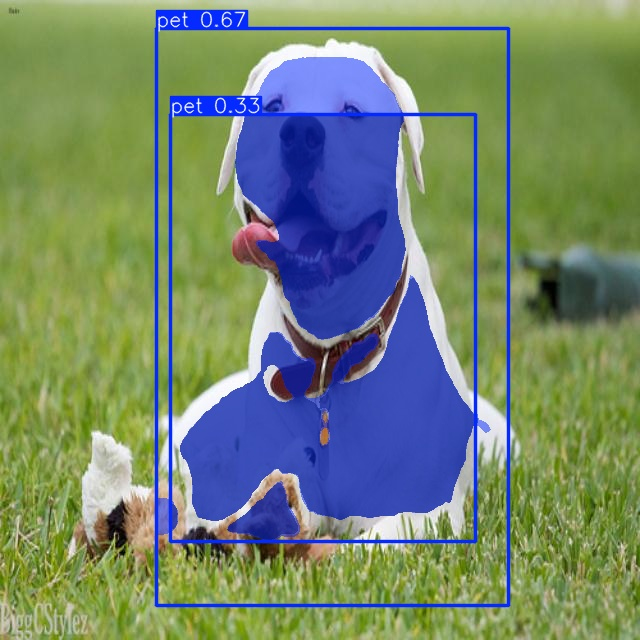

In [36]:
# 8. Visualize Prediction
from IPython.display import Image as IPImage, display

# The results object contains the path where the predictions were saved.
# results[0].save_dir gives the path to the directory containing the saved images.
output_path = os.path.join(results[0].save_dir, f"pet_{i}.jpg")
display(IPImage(filename=output_path))

In [37]:
#9. Validate the model
metrics = model.val()

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1371.6±631.3 MB/s, size: 39.9 KB)
val: Scanning /content/yolo_pet_data/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 32.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.1it/s 6.4s
                   all        100        140      0.857      0.643      0.718      0.457      0.851      0.643      0.697       0.43
Speed: 5.5ms preprocess, 14.0ms inference, 0.0ms loss, 11.4ms postprocess per image
Results saved to /content/runs/segment/val


In [38]:
print("map50-95")
print(metrics.box.map)
print("map50")
print(metrics.box.map50)
print("map75")
print(metrics.box.map75)
print("map50-95 list") # this is the metric for each class, but in this its only one class
print(metrics.box.maps)

map50-95
0.4569877112629902
map50
0.7179447342375594
map75
0.5341467633969388
map50-95 list
[    0.45699]


# QUIZ

YOLO Split and Evaluate

- Try to split the data into train and test.
- Perform training with the train data and evaluate with test data.
- Add augmentation (https://docs.ultralytics.com/guides/yolo-data-augmentation/#example-configurations)
- Achieve the highest mAP50-95 you can do!